# Online Gaming Engagement Classification

**Course:** BMDS2003 Data Science  
**Framework:** CRISP-DM  
**Task:** Multiclass classification of `EngagementLevel`

This executed notebook presents the completed analysis of 40,034 synthetic player profiles. It documents data validation, exploratory analysis, leakage-safe preparation, model comparison, hyperparameter tuning, evaluation, and model-artifact export.

> **Headline finding:** Random Forest is the selected model under the predeclared macro-F1 criterion, achieving 0.9153 mean five-fold cross-validated macro F1 and 0.9116 held-out test macro F1. Histogram Gradient Boosting is a close alternative at 0.9103 test macro F1. These results describe performance on the supplied synthetic labels; they are not evidence of causal effects or future retention performance.

## 1. Project Setup and Reproducibility

The notebook was executed with Python 3.12.13, pandas 3.0.3, scikit-learn 1.9.0, NumPy 2.5.1, Matplotlib 3.11.0, and Seaborn 0.13.2. The fixed seed 42 controls the stratified split and stochastic estimators. Runtime flags are enabled in the executed version, so the displayed outputs include the EDA plots, model comparison, tuning, and exported artifacts.

In [13]:
from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COLUMN = "EngagementLevel"
ID_COLUMN = "PlayerID"
EXCLUDED_MODEL_FEATURES = [ID_COLUMN, "PlayTimeHours"]
TARGET_ORDER = ["Low", "Medium", "High"]
EXPECTED_TARGET_LABELS = set(TARGET_ORDER)
DATA_FILENAME = "online_gaming_behavior_dataset.csv"

RUN_EDA_PLOTS = True
RUN_MODEL_SMOKE_TEST = True
RUN_FULL_MODEL_COMPARISON = True
RUN_HYPERPARAMETER_TUNING = True
EXPORT_SELECTED_MODEL = True

print(f"pandas={pd.__version__}; scikit-learn={sklearn.__version__}")

pandas=3.0.5; scikit-learn=1.9.0


## 2. Business and Analytical Objective

The analytical objective is to classify each player profile as `Low`, `Medium`, or `High` engagement using the supplied demographic and gaming-behaviour variables. The intended user is a game publisher's product and analytics team, which could use the predictions to prioritise segment-level investigation and user-experience analysis.

Macro F1 is the primary model-selection metric because `Medium` accounts for 48.39% of the data while `Low` and `High` each account for approximately 25.8%. Accuracy, weighted metrics, per-class results, confusion matrices, and one-versus-rest macro ROC-AUC provide supporting evidence. The dataset is cross-sectional and synthetic, and the target-generation procedure is not disclosed; consequently, the model is treated as descriptive decision support rather than a causal explanation or a validated forecast of future retention.

## 3. Data Loading and Validation

The dataset was loaded from `online_gaming_behavior_dataset.csv`, yielding 40,034 rows and 13 columns. The loader searches the current working directory and its parent, while validation checks that all required columns are present, the target is complete, and only the expected `Low`, `Medium`, and `High` labels occur. The displayed sample confirms the expected player-profile structure.

In [14]:
REQUIRED_COLUMNS = {
    "PlayerID", "Age", "Gender", "Location", "GameGenre",
    "PlayTimeHours", "InGamePurchases", "GameDifficulty",
    "SessionsPerWeek", "AvgSessionDurationMinutes", "PlayerLevel",
    "AchievementsUnlocked", "EngagementLevel",
}


def resolve_data_path(filename: str) -> Path:
    candidates = [Path.cwd() / filename, Path.cwd().parent / filename]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    tried = "\n".join(f"- {candidate.resolve()}" for candidate in candidates)
    raise FileNotFoundError(f"Could not locate {filename}. Tried:\n{tried}")


def validate_dataset(df: pd.DataFrame) -> None:
    if df.empty:
        raise ValueError("The dataset is empty; at least one record is required.")
    missing_columns = sorted(REQUIRED_COLUMNS.difference(df.columns))
    if missing_columns:
        raise ValueError(f"Dataset is missing required columns: {missing_columns}")
    if df[TARGET_COLUMN].isna().any():
        raise ValueError(f"{TARGET_COLUMN} contains missing values.")
    observed_labels = set(df[TARGET_COLUMN].unique())
    unexpected_labels = sorted(observed_labels.difference(EXPECTED_TARGET_LABELS))
    if unexpected_labels:
        raise ValueError(
            f"Unexpected {TARGET_COLUMN} labels: {unexpected_labels}; "
            f"expected only {sorted(EXPECTED_TARGET_LABELS)}."
        )


DATA_PATH = resolve_data_path(DATA_FILENAME)
PROJECT_ROOT = DATA_PATH.parent
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
for directory in [FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
validate_dataset(df)
print(f"Loaded {DATA_PATH.name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Loaded online_gaming_behavior_dataset.csv: 40,034 rows x 13 columns


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.2711,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.5260,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.2238,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.2654,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.5319,0,Medium,2,131,95,37,Medium


In [15]:
data_quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100),
    "unique": df.nunique(dropna=True),
}).sort_index()

print(f"Duplicate rows: {df.duplicated().sum():,}")
display(data_quality)

target_summary = (
    df[TARGET_COLUMN]
    .value_counts()
    .reindex(TARGET_ORDER)
    .rename("count")
    .to_frame()
)
target_summary["percentage"] = target_summary["count"].div(len(df)).mul(100)
display(target_summary)

Duplicate rows: 0


,dtype,non_null,missing,missing_pct,unique
AchievementsUnlocked,int64,40034,0,0.0000,50
Age,int64,40034,0,0.0000,35
AvgSessionDurationMinutes,int64,40034,0,0.0000,170
EngagementLevel,str,40034,0,0.0000,3
GameDifficulty,str,40034,0,0.0000,3
GameGenre,str,40034,0,0.0000,5
Gender,str,40034,0,0.0000,2
InGamePurchases,int64,40034,0,0.0000,2
Location,str,40034,0,0.0000,4
PlayTimeHours,float64,40034,0,0.0000,40034


,count,percentage
EngagementLevel,,
Low,10324,25.7881
Medium,19374,48.3939
High,10336,25.8181


### Data quality findings

All 40,034 records are complete and the audit found zero fully duplicated rows. The observed data types and category counts are consistent with the expected schema, and all three target labels are present. The target distribution is moderately imbalanced: `Low` = 10,324 (25.79%), `Medium` = 19,374 (48.39%), and `High` = 10,336 (25.82%).

Although no imputation is required for this file, the modelling pipelines retain median numeric imputation and most-frequent categorical imputation as safeguards for future inputs. Two semantic risks remain important. `PlayTimeHours` has an unclear definition alongside `AvgSessionDurationMinutes`, and the source does not disclose how `EngagementLevel` was generated. If the target was calculated directly from the predictor variables, the task may reproduce a simulation rule rather than provide independently useful prediction.

## 4. Data Understanding and Exploratory Data Analysis

The executed EDA describes the target balance, numeric and categorical distributions, class-conditioned numeric behaviour, and pairwise Pearson correlations. The strongest visible separation between engagement classes occurs in `SessionsPerWeek` and `AvgSessionDurationMinutes`: higher-engagement profiles generally show more frequent and longer sessions. The categorical distributions are comparatively similar across the target classes, while the correlation heatmap shows association among numeric predictors without establishing causation.

In [16]:
NUMERIC_FEATURES = [
    "Age", "PlayTimeHours", "InGamePurchases", "SessionsPerWeek",
    "AvgSessionDurationMinutes", "PlayerLevel", "AchievementsUnlocked",
]
CATEGORICAL_FEATURES = [
    "Gender", "Location", "GameGenre", "GameDifficulty",
]

display(df[NUMERIC_FEATURES].describe().T)

categorical_summary = {
    column: df[column].value_counts(dropna=False).rename("count").to_frame()
    for column in CATEGORICAL_FEATURES
}
for column, summary in categorical_summary.items():
    print(f"\n{column}")
    display(summary)

,count,mean,std,min,25%,50%,75%,max
Age,"40,034.0000",31.9925,10.0432,15.0000,23.0000,32.0000,41.0000,49.0000
PlayTimeHours,"40,034.0000",12.0244,6.9146,0.0001,6.0675,12.0080,17.9638,23.9996
InGamePurchases,"40,034.0000",0.2009,0.4006,0.0000,0.0000,0.0000,0.0000,1.0000
SessionsPerWeek,"40,034.0000",9.4718,5.7637,0.0000,4.0000,9.0000,14.0000,19.0000
AvgSessionDurationMinutes,"40,034.0000",94.7923,49.0114,10.0000,52.0000,95.0000,137.0000,179.0000
PlayerLevel,"40,034.0000",49.6556,28.5884,1.0000,25.0000,49.0000,74.0000,99.0000
AchievementsUnlocked,"40,034.0000",24.5265,14.4307,0.0000,12.0000,25.0000,37.0000,49.0000



Gender


,count
Gender,
Male,23959
Female,16075



Location


,count
Location,
USA,16000
Europe,12004
Asia,8095
Other,3935



GameGenre


,count
GameGenre,
Sports,8048
Action,8039
Strategy,8012
Simulation,7983
RPG,7952



GameDifficulty


,count
GameDifficulty,
Easy,20015
Medium,12011
Hard,8008


In [17]:
# Reusable association summaries used by the extended EDA figures.
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency


def cramers_v(contingency: pd.DataFrame) -> float:
    """Return bias-corrected Cramér's V for a contingency table."""
    observations = contingency.to_numpy()
    sample_size = observations.sum()
    if sample_size == 0 or min(observations.shape) < 2:
        return 0.0

    chi2 = chi2_contingency(observations, correction=False).statistic
    phi2 = chi2 / sample_size
    rows, columns = observations.shape
    phi2_corrected = max(0.0, phi2 - ((columns - 1) * (rows - 1)) / (sample_size - 1))
    rows_corrected = rows - ((rows - 1) ** 2) / (sample_size - 1)
    columns_corrected = columns - ((columns - 1) ** 2) / (sample_size - 1)
    denominator = min(columns_corrected - 1, rows_corrected - 1)
    return float(np.sqrt(phi2_corrected / denominator)) if denominator > 0 else 0.0


def engagement_composition_table(df: pd.DataFrame, feature: str) -> pd.DataFrame:
    """Return observed target proportions within every category of a feature."""
    table = pd.crosstab(df[feature], df["EngagementLevel"])
    target_order = ["Low", "Medium", "High"]
    target_columns = [target for target in target_order if target in table.columns]
    table = table[target_columns]
    result = (
        table.div(table.sum(axis=1), axis=0)
        .mul(100)
        .stack()
        .rename("Percentage")
        .reset_index()
    )
    return result[result["Percentage"] > 0].reset_index(drop=True)


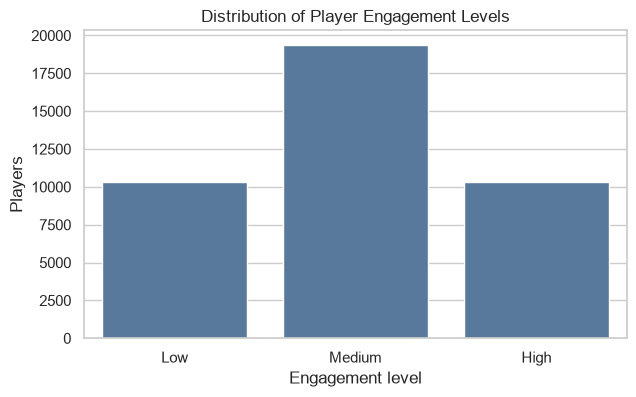

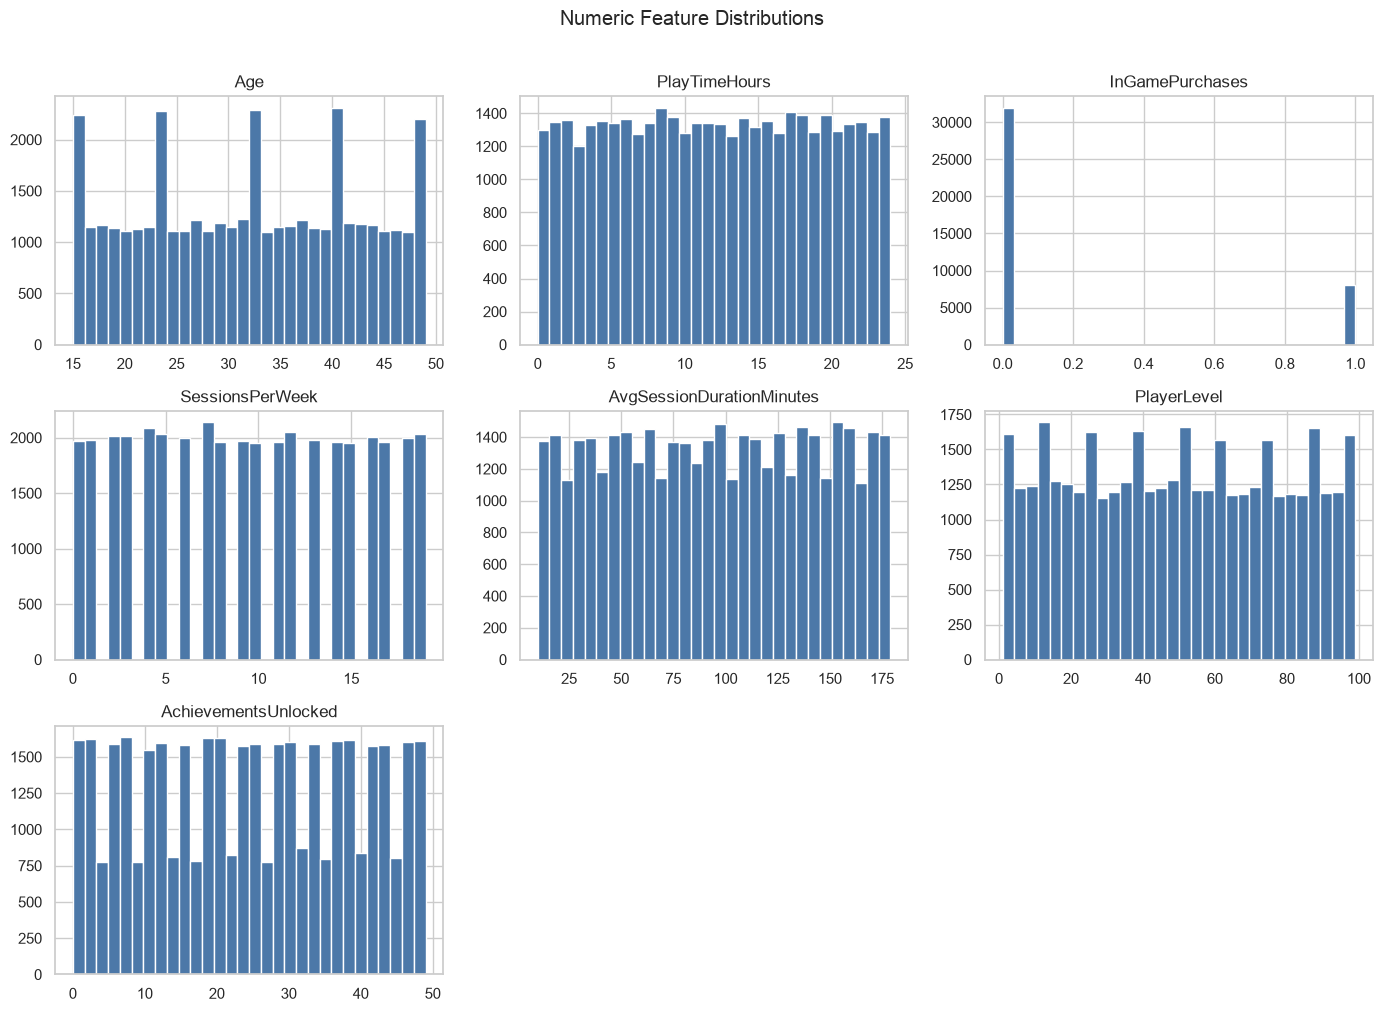

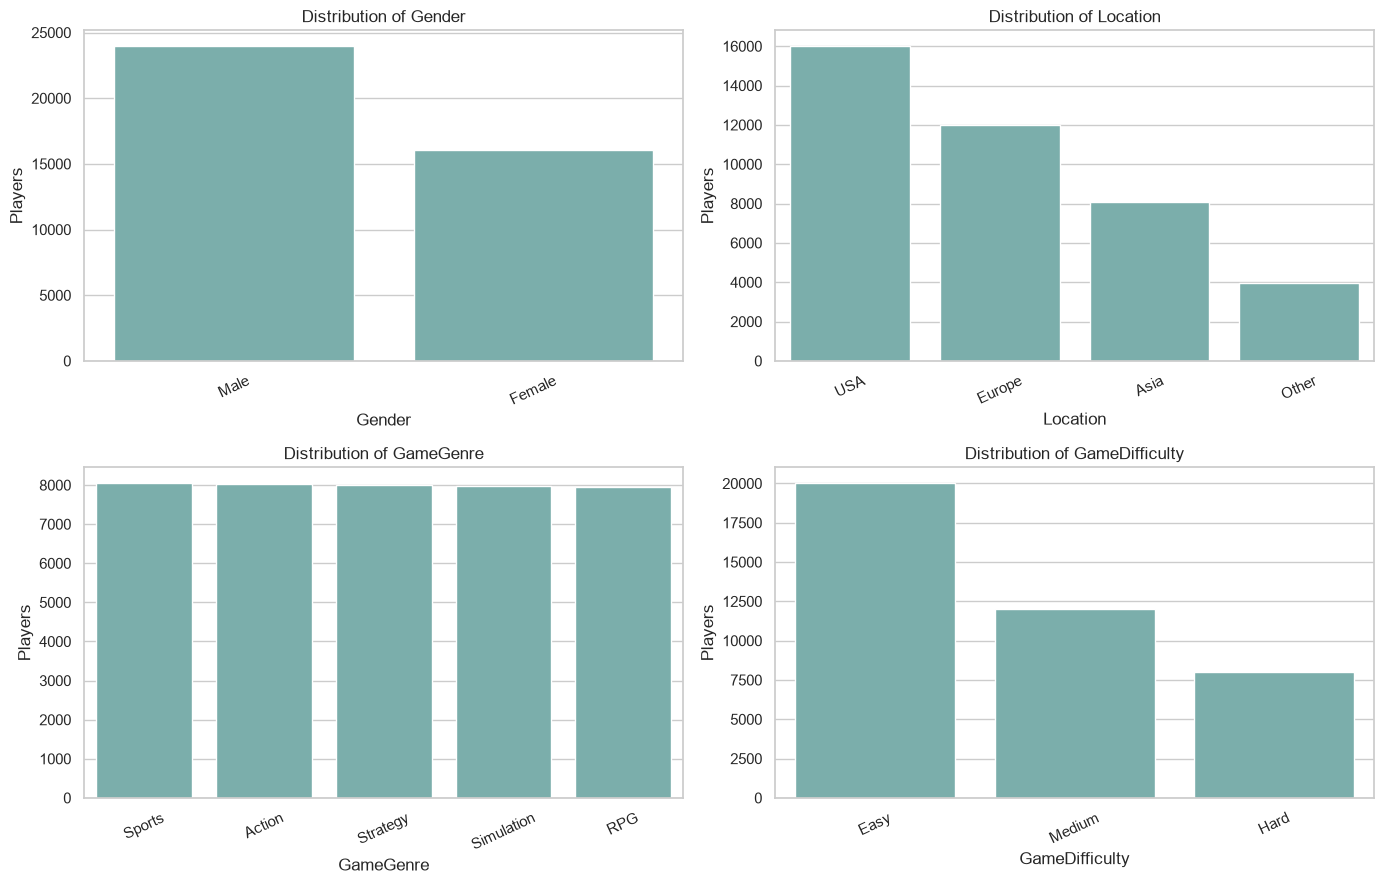

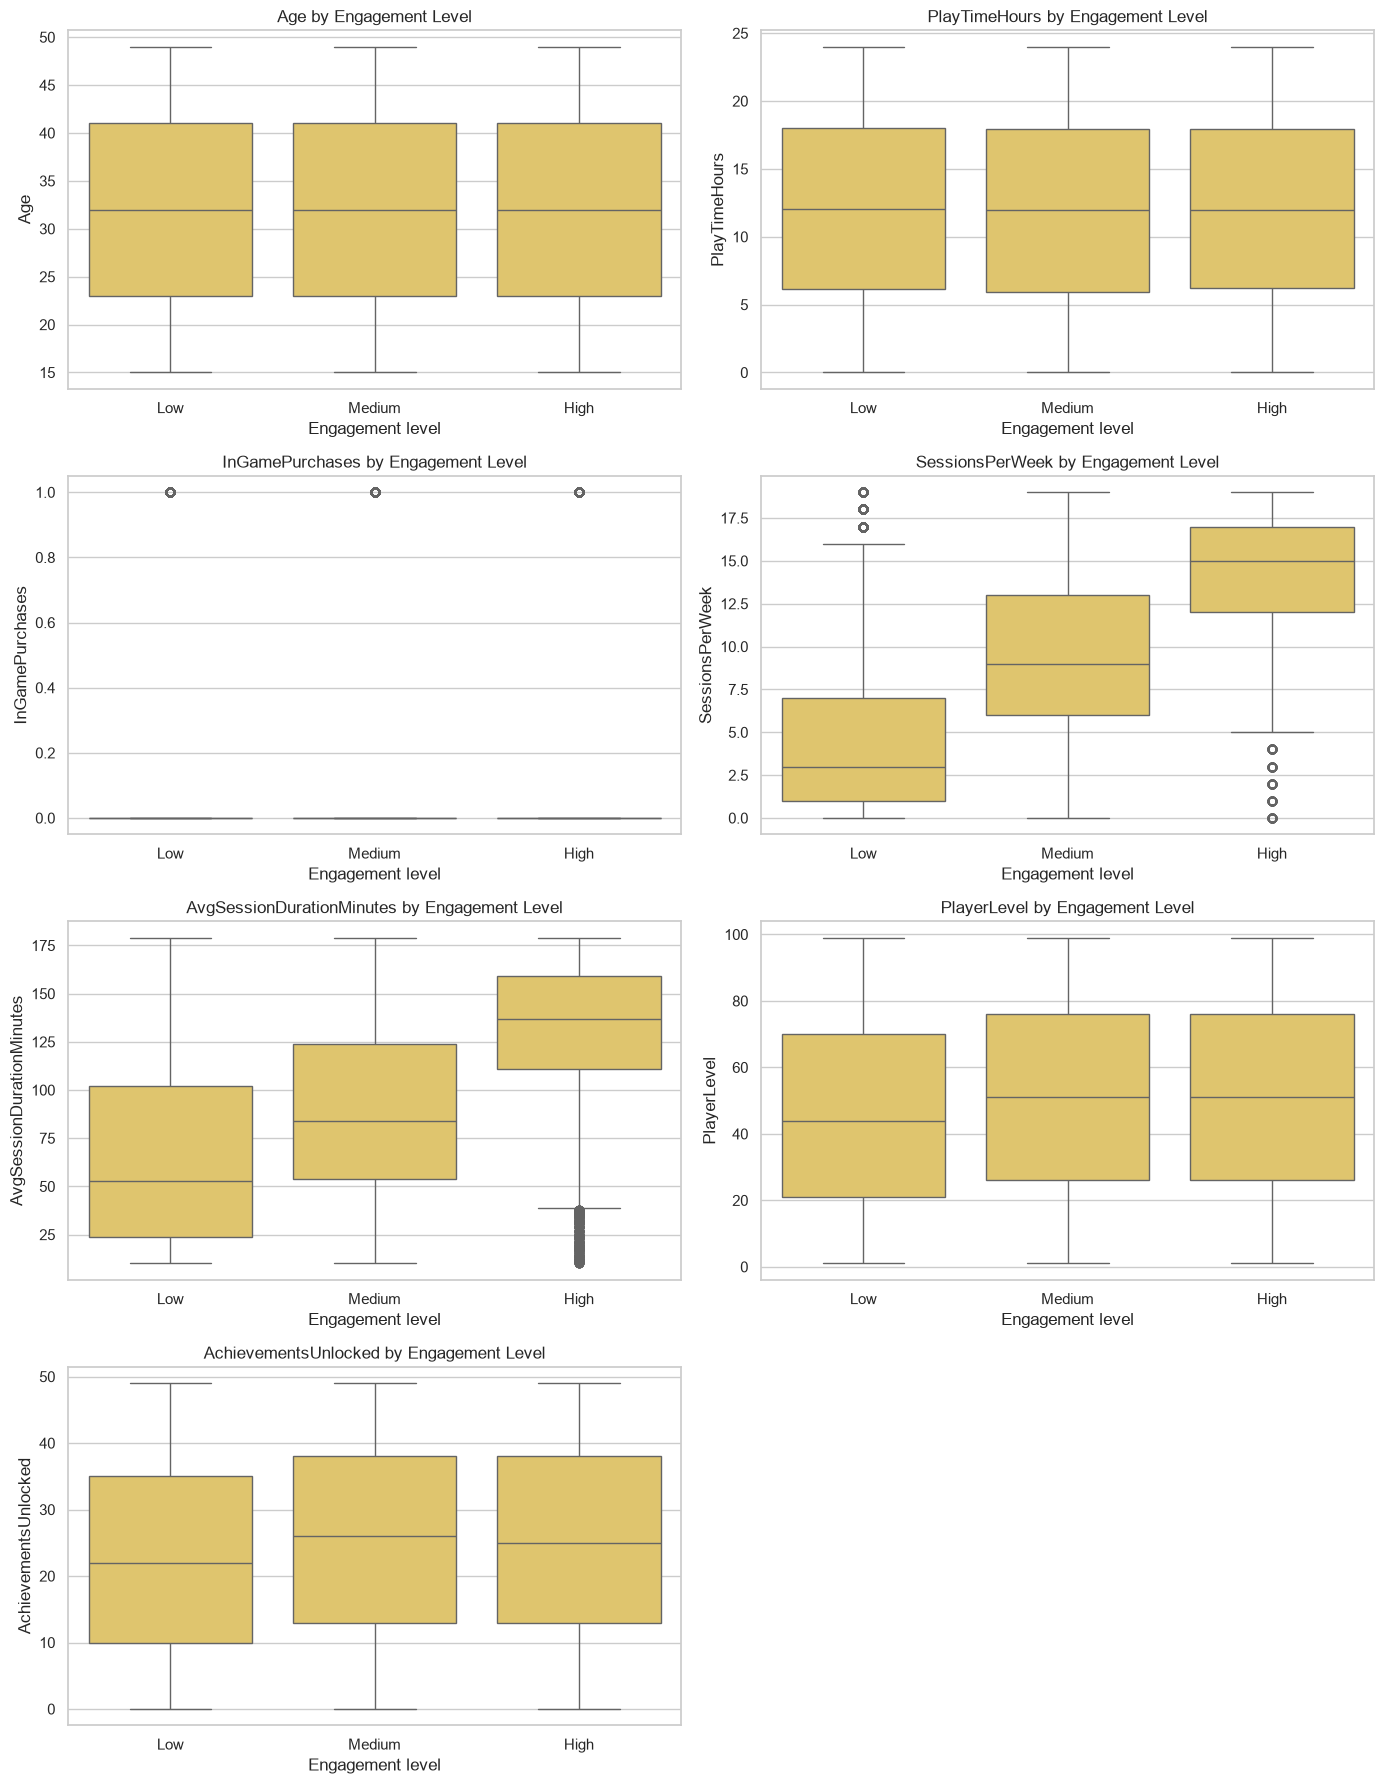

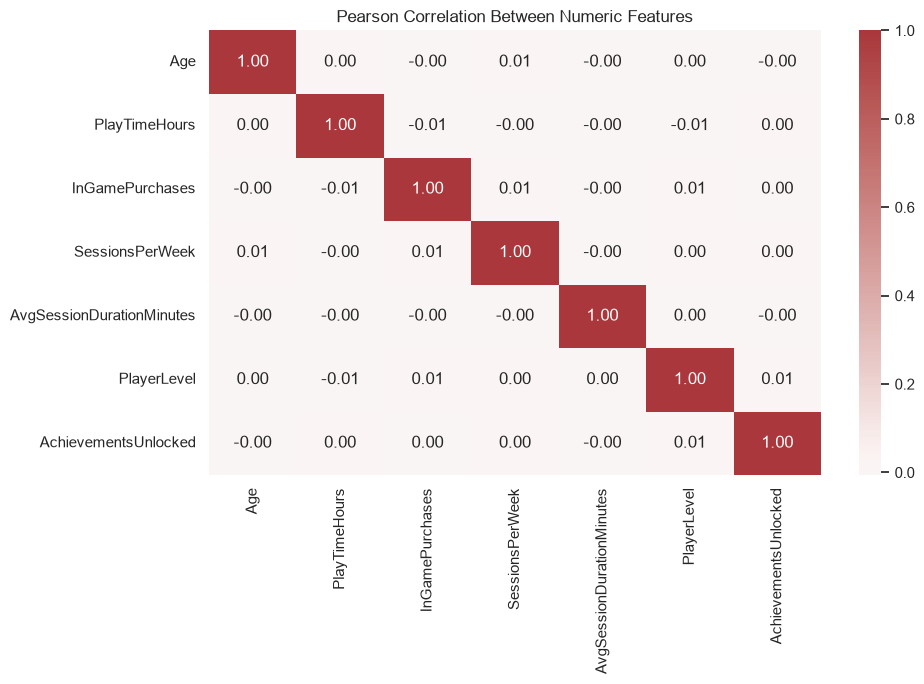

,Feature,ChiSquare,PValue,CramersV,SampleSize
0,Gender,1.1808,0.5541,0.0000,40034
1,Location,3.5571,0.7364,0.0000,40034
2,GameGenre,8.6112,0.3761,0.0028,40034
3,GameDifficulty,4.1733,0.3831,0.0015,40034
4,InGamePurchases,2.9814,0.2252,0.0050,40034


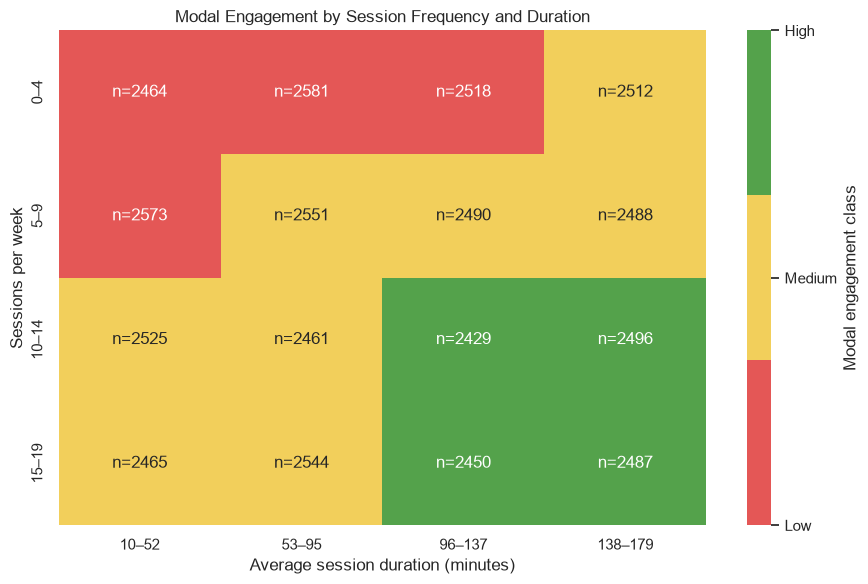

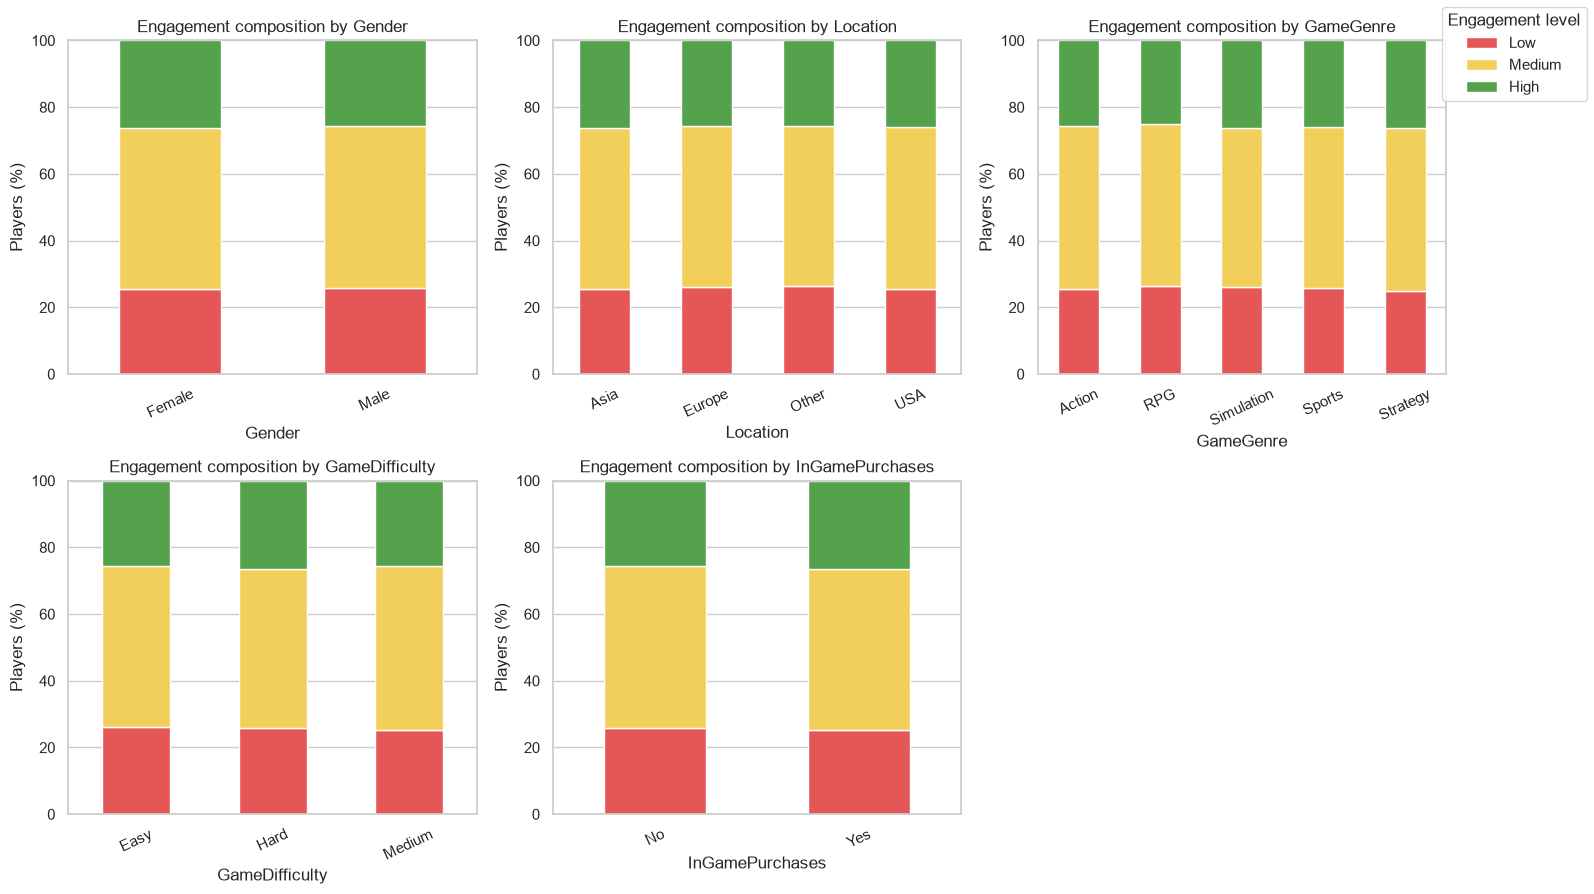

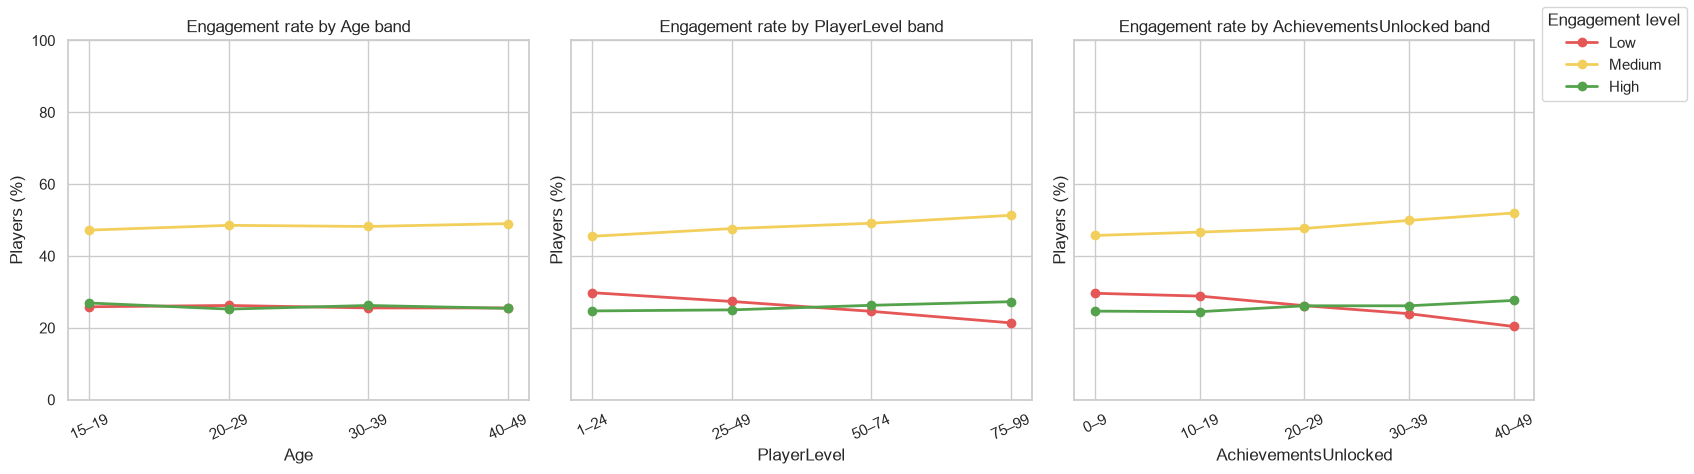

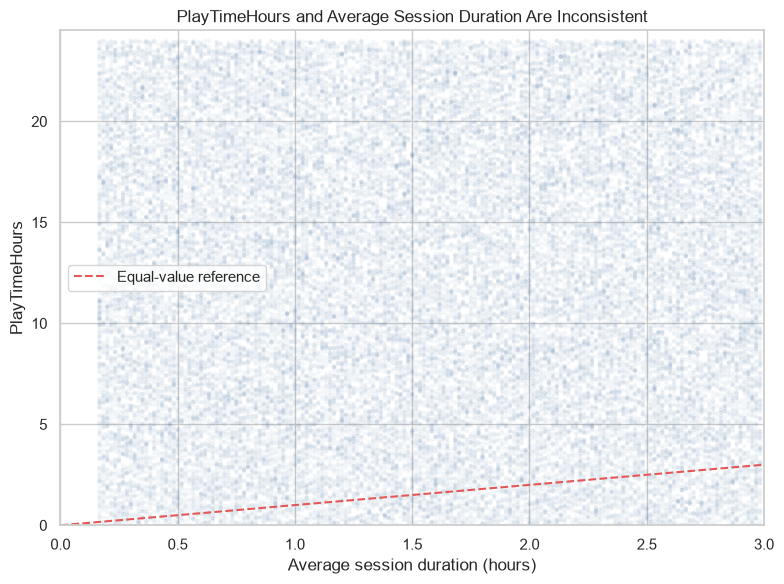

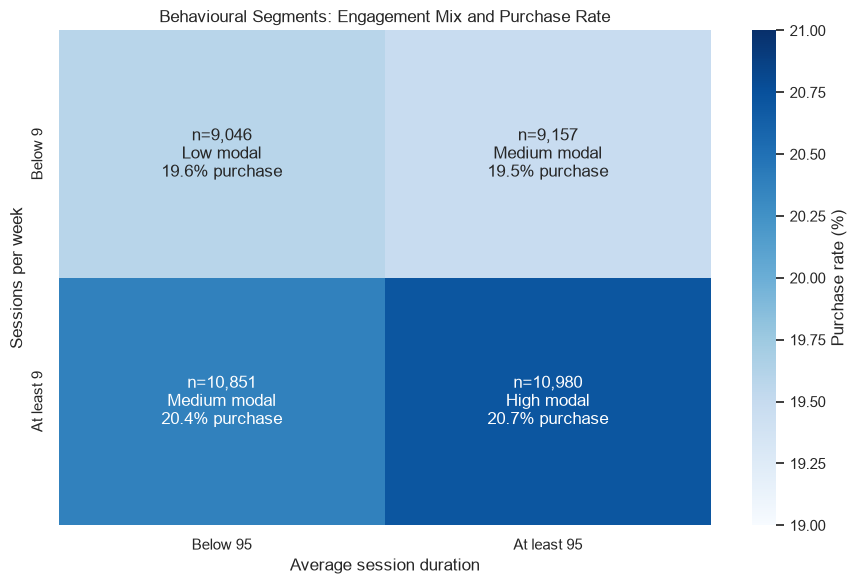

In [18]:
def save_and_show(fig: plt.Figure, filename: str) -> None:
    # Save a high-resolution copy, display it in the notebook, then free its memory.
    fig.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


if RUN_EDA_PLOTS:
    # Count players in each target class to check engagement-level balance.
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.countplot(data=df, x=TARGET_COLUMN, order=TARGET_ORDER, ax=ax, color="#4C78A8")
    ax.set(title="Distribution of Player Engagement Levels", xlabel="Engagement level", ylabel="Players")
    save_and_show(fig, "target_distribution.png")

    # Plot histograms to reveal each numeric feature's shape, spread, and skew.
    df[NUMERIC_FEATURES].hist(figsize=(14, 10), bins=30, color="#4C78A8", edgecolor="white")
    fig = plt.gcf()
    fig.suptitle("Numeric Feature Distributions", y=1.01)
    fig.tight_layout()
    save_and_show(fig, "numeric_distributions.png")

    # Compare category frequencies, ordering bars from most to least common.
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, column in zip(axes.flat, CATEGORICAL_FEATURES):
        order = df[column].value_counts().index
        sns.countplot(data=df, x=column, order=order, ax=ax, color="#72B7B2")
        ax.set(title=f"Distribution of {column}", xlabel=column, ylabel="Players")
        ax.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    save_and_show(fig, "categorical_distributions.png")

    # Use boxplots to compare numeric distributions and outliers across engagement levels.
    fig, axes = plt.subplots(4, 2, figsize=(14, 18))
    for ax, column in zip(axes.flat, NUMERIC_FEATURES):
        sns.boxplot(data=df, x=TARGET_COLUMN, y=column, order=TARGET_ORDER, ax=ax, color="#F2CF5B")
        ax.set(title=f"{column} by Engagement Level", xlabel="Engagement level", ylabel=column)
    axes.flat[-1].axis("off")
    fig.tight_layout()
    save_and_show(fig, "numeric_features_by_target.png")

    # Visualize pairwise Pearson correlations to spot related numeric features.
    fig, ax = plt.subplots(figsize=(10, 7))
    correlation = df[NUMERIC_FEATURES].corr()
    sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
    ax.set_title("Pearson Correlation Between Numeric Features")
    fig.tight_layout()
    save_and_show(fig, "numeric_correlation_heatmap.png")

    # Extended EDA: joint behavioural patterns, categorical effects, and measurement checks.
    from scipy.stats import chi2_contingency
    from matplotlib.colors import ListedColormap

    categorical_target_features = CATEGORICAL_FEATURES + ["InGamePurchases"]
    association_rows = []
    for feature in categorical_target_features:
        contingency = pd.crosstab(df[feature], df[TARGET_COLUMN]).reindex(columns=TARGET_ORDER, fill_value=0)
        chi2_result = chi2_contingency(contingency, correction=False)
        association_rows.append({
            "Feature": feature,
            "ChiSquare": chi2_result.statistic,
            "PValue": chi2_result.pvalue,
            "CramersV": cramers_v(contingency),
            "SampleSize": int(contingency.to_numpy().sum()),
        })
    association_table = pd.DataFrame(association_rows)
    association_table.to_csv(TABLES_DIR / "categorical_target_associations.csv", index=False)
    display(association_table)

    # Show the modal engagement class within combinations of session frequency and duration bands.
    session_band = pd.cut(
        df["SessionsPerWeek"], bins=[-1, 4, 9, 14, 19],
        labels=["0–4", "5–9", "10–14", "15–19"], include_lowest=True,
    )
    duration_band = pd.cut(
        df["AvgSessionDurationMinutes"], bins=[9, 52, 95, 137, 179],
        labels=["10–52", "53–95", "96–137", "138–179"], include_lowest=True,
    )
    session_duration = pd.DataFrame({"Session band": session_band, "Duration band": duration_band, TARGET_COLUMN: df[TARGET_COLUMN]})
    class_counts = session_duration.groupby(["Session band", "Duration band", TARGET_COLUMN], observed=True).size().unstack(fill_value=0).reindex(columns=TARGET_ORDER, fill_value=0)
    modal_codes = class_counts.idxmax(axis=1).map({label: code for code, label in enumerate(TARGET_ORDER)}).unstack()
    cell_counts = class_counts.sum(axis=1).unstack()
    annotations = cell_counts.fillna(0).astype(int).astype(str).apply(lambda column: np.where(column.astype(int) > 0, "n=" + column, ""))
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.heatmap(
        modal_codes, mask=cell_counts.isna(), cmap=ListedColormap(["#E45756", "#F2CF5B", "#54A24B"]),
        vmin=0, vmax=2, annot=annotations, fmt="", cbar_kws={"ticks": [0, 1, 2], "label": "Modal engagement class"}, ax=ax,
    )
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticklabels(TARGET_ORDER)
    ax.set(title="Modal Engagement by Session Frequency and Duration", xlabel="Average session duration (minutes)", ylabel="Sessions per week")
    fig.tight_layout()
    save_and_show(fig, "engagement_session_heatmap.png")

    # Compare class composition within each categorical group; association magnitudes are exported above.
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, feature in zip(axes.flat, categorical_target_features):
        plot_df = df.copy()
        if feature == "InGamePurchases":
            plot_df[feature] = plot_df[feature].map({0: "No", 1: "Yes"})
        composition = pd.crosstab(plot_df[feature], plot_df[TARGET_COLUMN], normalize="index").reindex(columns=TARGET_ORDER, fill_value=0) * 100
        composition.plot(kind="bar", stacked=True, color=["#E45756", "#F2CF5B", "#54A24B"], ax=ax, legend=False)
        ax.set(title=f"Engagement composition by {feature}", xlabel=feature, ylabel="Players (%)", ylim=(0, 100))
        ax.tick_params(axis="x", rotation=25)
    axes.flat[-1].axis("off")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Engagement level", loc="upper right")
    fig.tight_layout(rect=(0, 0, 0.92, 1))
    save_and_show(fig, "categorical_composition_by_target.png")

    # Test for non-linear class patterns across interpretable ordered bands.
    binned_features = {
        "Age": ([-1, 19, 29, 39, 49], ["15–19", "20–29", "30–39", "40–49"]),
        "PlayerLevel": ([0, 24, 49, 74, 99], ["1–24", "25–49", "50–74", "75–99"]),
        "AchievementsUnlocked": ([-1, 9, 19, 29, 39, 49], ["0–9", "10–19", "20–29", "30–39", "40–49"]),
    }
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
    for ax, (feature, (bins, labels)) in zip(axes, binned_features.items()):
        bands = pd.cut(df[feature], bins=bins, labels=labels, include_lowest=True)
        rates = pd.crosstab(bands, df[TARGET_COLUMN], normalize="index").reindex(columns=TARGET_ORDER, fill_value=0) * 100
        for engagement, color in zip(TARGET_ORDER, ["#E45756", "#F2CF5B", "#54A24B"]):
            ax.plot(rates.index.astype(str), rates[engagement], marker="o", linewidth=2, label=engagement, color=color)
        ax.set(title=f"Engagement rate by {feature} band", xlabel=feature, ylabel="Players (%)", ylim=(0, 100))
        ax.tick_params(axis="x", rotation=25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Engagement level", loc="upper right")
    fig.tight_layout(rect=(0, 0, 0.92, 1))
    save_and_show(fig, "binned_engagement_rates.png")

    # Audit whether the two purported per-session play-time measures agree when expressed in hours.
    duration_hours = df["AvgSessionDurationMinutes"] / 60
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(duration_hours, df["PlayTimeHours"], alpha=0.06, s=10, color="#4C78A8", edgecolors="none")
    ax.plot([0, 3], [0, 3], linestyle="--", color="#E45756", label="Equal-value reference")
    ax.set(title="PlayTimeHours and Average Session Duration Are Inconsistent", xlabel="Average session duration (hours)", ylabel="PlayTimeHours", xlim=(0, 3), ylim=(0, 24.5))
    ax.legend()
    fig.tight_layout()
    save_and_show(fig, "playtime_duration_consistency.png")

    # Summarise practical behavioural segments using median splits that are easy to reproduce.
    sessions_median = df["SessionsPerWeek"].median()
    duration_median = df["AvgSessionDurationMinutes"].median()
    segment_df = df.assign(
        SessionSegment=np.where(df["SessionsPerWeek"] < sessions_median, f"Below {sessions_median:.0f}", f"At least {sessions_median:.0f}"),
        DurationSegment=np.where(df["AvgSessionDurationMinutes"] < duration_median, f"Below {duration_median:.0f}", f"At least {duration_median:.0f}"),
    )
    segment_summary = segment_df.groupby(["SessionSegment", "DurationSegment"], observed=True).agg(
        Players=(TARGET_COLUMN, "size"), PurchaseRate=("InGamePurchases", "mean"),
    )
    segment_modes = segment_df.groupby(["SessionSegment", "DurationSegment"], observed=True)[TARGET_COLUMN].agg(lambda values: values.value_counts().reindex(TARGET_ORDER, fill_value=0).idxmax())
    segment_summary["ModalEngagement"] = segment_modes
    purchase_grid = segment_summary["PurchaseRate"].unstack().reindex(index=[f"Below {sessions_median:.0f}", f"At least {sessions_median:.0f}"], columns=[f"Below {duration_median:.0f}", f"At least {duration_median:.0f}"])
    annotation_grid = segment_summary.apply(lambda row: f"n={row['Players']:,}\n{row['ModalEngagement']} modal\n{row['PurchaseRate']:.1%} purchase", axis=1).unstack().reindex(index=purchase_grid.index, columns=purchase_grid.columns)
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.heatmap(purchase_grid * 100, annot=annotation_grid, fmt="", cmap="Blues", vmin=19, vmax=21, cbar_kws={"label": "Purchase rate (%)"}, ax=ax)
    ax.set(title="Behavioural Segments: Engagement Mix and Purchase Rate", xlabel="Average session duration", ylabel="Sessions per week")
    fig.tight_layout()
    save_and_show(fig, "behavioural_segment_summary.png")

else:
    print("EDA plots are disabled; no EDA figures were generated.")

### EDA interpretation

The numeric ranges are plausible for the supplied synthetic records, so no observations were removed or capped. The apparent IQR flags for the binary `InGamePurchases` variable are an artefact of applying a continuous-variable rule to a 0/1 indicator, not evidence of anomalous purchases. Class-conditioned plots show that the two session measures carry the clearest signal, but those patterns should be interpreted as associations in the supplied data. They do not show that increasing session frequency or duration would cause engagement to increase.

## 5. Data Preparation

The final predictor set contains six numeric variables (`Age`, `InGamePurchases`, `SessionsPerWeek`, `AvgSessionDurationMinutes`, `PlayerLevel`, and `AchievementsUnlocked`) and four categorical variables (`Gender`, `Location`, `GameGenre`, and `GameDifficulty`). `PlayerID` is excluded because it is an identifier, while `PlayTimeHours` is excluded because its source definition is ambiguous beside the separate session-duration measure. Both remain available for data-quality analysis but do not enter the predictor matrices. The split occurs before preprocessing, and every learned transformation is contained within a scikit-learn pipeline to prevent leakage.

In [19]:
X = df.drop(columns=[TARGET_COLUMN, *EXCLUDED_MODEL_FEATURES])
y = df[TARGET_COLUMN].copy()

if X.empty or y.empty:
    raise ValueError("Predictors and target must both contain data.")
unexpected_model_columns = set(EXCLUDED_MODEL_FEATURES + [TARGET_COLUMN]).intersection(X.columns)
if unexpected_model_columns:
    raise AssertionError(
        f"Excluded identifier, feature, or target leaked into the predictor matrix: "
        f"{sorted(unexpected_model_columns)}"
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.concat(
    {
        "Full": y.value_counts(normalize=True).reindex(TARGET_ORDER),
        "Train": y_train.value_counts(normalize=True).reindex(TARGET_ORDER),
        "Test": y_test.value_counts(normalize=True).reindex(TARGET_ORDER),
    },
    axis=1,
).mul(100)
print(f"Train rows: {len(X_train):,}; test rows: {len(X_test):,}")
display(split_summary.rename_axis("EngagementLevel"))

Train rows: 32,027; test rows: 8,007


,Full,Train,Test
EngagementLevel,,,
Low,25.7881,25.7876,25.7899
Medium,48.3939,48.3935,48.3952
High,25.8181,25.8188,25.8149


### Train-test split and leakage control

The data were split 80:20 with `random_state=42`, producing 32,027 training records and 8,007 test records. Stratification preserved the class proportions in both partitions. The training data were used for fitting and five-fold tuning; the test data remained untouched until the final comparison, providing the held-out estimate reported below.

In [20]:
MODEL_NUMERIC_FEATURES = [
    "Age", "InGamePurchases", "SessionsPerWeek",
    "AvgSessionDurationMinutes", "PlayerLevel", "AchievementsUnlocked",
]


def build_preprocessor(
    scale_numeric: bool = True,
    dense_output: bool = False,
) -> ColumnTransformer:
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=not dense_output,
            ),
        ),
    ])

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, MODEL_NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        sparse_threshold=0.0 if dense_output else 0.3,
    )


validation_size = min(2_000, len(X_train))
validation_rows = X_train.sample(n=validation_size, random_state=RANDOM_STATE)
transformed_check = build_preprocessor(
    scale_numeric=True,
    dense_output=True,
).fit_transform(validation_rows)
if np.isnan(np.asarray(transformed_check, dtype=float)).any():
    raise AssertionError("Preprocessing produced missing values.")
print(f"Preprocessing check passed: {transformed_check.shape}")

Preprocessing check passed: (2000, 20)


### Preparation decisions and verification

Categorical variables are one-hot encoded, producing 14 indicator columns. Numeric variables are median-imputed; categorical variables use most-frequent imputation. Logistic Regression and K-Nearest Neighbours receive standardised numeric features because their coefficients and distances are scale-sensitive, while the tree ensembles use unscaled numeric values. `handle_unknown="ignore"` allows a valid category not seen during training to pass through the encoder.

The preprocessing check transformed 2,000 training rows into 20 numeric columns with no missing values. No outlier removal or capping was applied: the continuous predictors remained within plausible ranges, and the binary purchase indicator was retained unchanged.

## 6. Shared Evaluation Utilities

All models use the same evaluation contract: each pipeline is fitted on the training data, evaluated on the held-out test data, and scored with accuracy, macro and weighted precision/recall/F1, one-versus-rest macro ROC-AUC where probabilities are available, fit time, classification reports, and confusion matrices. Macro F1 is the primary criterion because it weights `Low`, `Medium`, and `High` equally.

In [21]:
def evaluate_model(
    name: str,
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> tuple[dict, pd.DataFrame, np.ndarray]:
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)
    macro = precision_recall_fscore_support(
        y_test, test_predictions, average="macro", zero_division=0
    )
    weighted = precision_recall_fscore_support(
        y_test, test_predictions, average="weighted", zero_division=0
    )

    metrics = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_predictions),
        "test_accuracy": accuracy_score(y_test, test_predictions),
        "macro_precision": macro[0],
        "macro_recall": macro[1],
        "macro_f1": macro[2],
        "weighted_precision": weighted[0],
        "weighted_recall": weighted[1],
        "weighted_f1": weighted[2],
        "macro_roc_auc_ovr": np.nan,
        "fit_seconds": fit_seconds,
    }

    if hasattr(pipeline, "predict_proba"):
        probabilities = pipeline.predict_proba(X_test)
        metrics["macro_roc_auc_ovr"] = roc_auc_score(
            y_test,
            probabilities,
            labels=list(pipeline.classes_),
            multi_class="ovr",
            average="macro",
        )

    report = pd.DataFrame(
        classification_report(
            y_test,
            test_predictions,
            labels=TARGET_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T
    matrix = confusion_matrix(y_test, test_predictions, labels=TARGET_ORDER)
    return metrics, report, matrix

In [22]:
MODEL_PIPELINES = {
    "Logistic Regression (Baseline)": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=True, dense_output=False)),
        ("model", LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE)),
    ]),
    "K-Nearest Neighbours": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=True, dense_output=False)),
        ("model", KNeighborsClassifier()),
    ]),
    "Decision Tree": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=False, dense_output=False)),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=False, dense_output=False)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]),
    "Histogram Gradient Boosting": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=False, dense_output=True)),
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    "RBF Support Vector Machine": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=True, dense_output=False)),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ]),
}

assert set(MODEL_PIPELINES) == {
    "Logistic Regression (Baseline)",
    "K-Nearest Neighbours",
    "Decision Tree",
    "Random Forest",
    "Histogram Gradient Boosting",
    "RBF Support Vector Machine",
}
print("Model pipelines:")
for model_name in MODEL_PIPELINES:
    print(f"- {model_name}")

Model pipelines:
- Logistic Regression (Baseline)
- K-Nearest Neighbours
- Decision Tree
- Random Forest
- Histogram Gradient Boosting
- RBF Support Vector Machine


## 7. Candidate Model Design

The six candidate pipelines are defined once in `MODEL_PIPELINES` above. This keeps preprocessing consistent across models; the comparison and tuning sections below execute the candidates under the same train-test split and evaluation contract.

### 7.1 Multinomial Logistic Regression (Baseline)

Multinomial Logistic Regression provides a transparent linear baseline with class-probability outputs. Its linear decision boundaries make it relatively easy to explain, but they limit the model's ability to capture nonlinear relationships and interactions. The smoke-test cell below checks that the baseline pipeline executes; the full baseline fit is included in the shared comparison and tuning workflow. After tuning, the baseline achieved 0.8182 mean cross-validated macro F1 and 0.8120 test macro F1.

### 7.2 K-Nearest Neighbours

K-Nearest Neighbours provides a distance-based nonlinear comparison. It is sensitive to scaling, neighbourhood size, and feature representation, and prediction becomes more expensive as the training set grows. The tuned search selected `n_neighbors=31`, Euclidean distance (`p=2`), and uniform weights. It achieved 0.7984 mean cross-validated macro F1 and 0.7988 test macro F1, below the other final candidates and particularly affected by the majority `Medium` class.

### 7.3 Decision Tree

Decision Tree is an interpretable nonlinear benchmark. It learns a sequence of feature-threshold rules that can represent interactions without numeric scaling, but an unrestricted tree can fit noise and become unstable when the training data changes. Tuning maximum depth and minimum samples per leaf controls this complexity, while the class-weight option tests whether giving the smaller Low and High classes more influence improves macro F1. Its role is to show whether the stronger ensemble methods gain value beyond a single tree.

### 7.4 Random Forest

Random Forest is a bagged tree ensemble that can model nonlinearities and interactions without numeric scaling. The selected configuration uses 200 trees, maximum depth 24, minimum leaf size 1, and `max_features=0.7`. It achieved the strongest mean cross-validated macro F1 (0.9153), test macro F1 (0.9116), and test accuracy (0.9164). Test recall was reasonably balanced across `Low` (0.8944), `Medium` (0.9466), and `High` (0.8820). Its perfect training accuracy versus 0.9164 test accuracy is an explicit overfitting warning.

### 7.5 Histogram Gradient Boosting

Histogram Gradient Boosting provides a second nonlinear ensemble with sequential error correction and histogram-based training. The selected configuration uses learning rate 0.03, 100 iterations, 63 leaf nodes, and L2 regularisation of 1.0. It achieved 0.9134 mean cross-validated macro F1 and 0.9103 test macro F1, making it a close alternative to Random Forest. Its near-tied performance means model choice should also consider stability, interpretation, and refit cost.

### 7.6 RBF Support Vector Machine

The RBF Support Vector Machine is a margin-based nonlinear classifier. Its radial-basis-function kernel can model curved class boundaries by comparing each player profile with influential training observations, while the regularisation parameter `C` controls the trade-off between a wider margin and fitting training errors. `gamma` controls how local each profile's influence is. Numeric features are standardised because the RBF kernel depends on distances; probability estimates are enabled so its ROC-AUC and prediction confidence can be evaluated under the same contract as the other probability-capable models. The grid is intentionally compact because kernel SVM fitting is comparatively expensive on this 40,034-record dataset.

In [23]:
if RUN_MODEL_SMOKE_TEST:
    if len(X_train) > 5_000:
        X_smoke, _, y_smoke, _ = train_test_split(
            X_train,
            y_train,
            train_size=5_000,
            random_state=RANDOM_STATE,
            stratify=y_train,
        )
    else:
        X_smoke, y_smoke = X_train, y_train

    smoke_pipeline = clone(MODEL_PIPELINES["Logistic Regression (Baseline)"])
    smoke_metrics, smoke_report, smoke_matrix = evaluate_model(
        "Logistic Regression (Baseline) — smoke test",
        smoke_pipeline,
        X_smoke,
        X_test,
        y_smoke,
        y_test,
    )
    print("Smoke-test metrics (not final tuned results):")
    display(pd.DataFrame([smoke_metrics]).set_index("model"))
else:
    print("Baseline smoke test disabled.")

Smoke-test metrics (not final tuned results):


,train_accuracy,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,macro_roc_auc_ovr,fit_seconds
model,,,,,,,,,,
Logistic Regression (Baseline) — smoke test,0.8202,0.8177,0.8254,0.7994,0.8103,0.8192,0.8177,0.8163,0.9126,0.0383


## 8. Model Comparison

The initial comparison evaluates the four default pipelines on the same stratified split before tuning. Histogram Gradient Boosting produced the strongest untuned test macro F1 (0.9109), followed by Random Forest (0.8896), Logistic Regression (0.8120), and K-Nearest Neighbours (0.7422). These results establish the effect of model family and provide context for the tuned comparison; the final selection is based on the cross-validated and held-out results below.

,model,train_accuracy,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,macro_roc_auc_ovr,fit_seconds
0,Histogram Gradient Boosting,0.9292,0.9157,0.9158,0.9065,0.9109,0.9157,0.9157,0.9154,0.9440,2.1658
1,RBF Support Vector Machine,0.9170,0.8996,0.9036,0.8869,0.8944,0.9003,0.8996,0.8991,0.9420,57.3895
2,Random Forest,1.0000,0.8950,0.8997,0.8814,0.8896,0.8958,0.8950,0.8944,0.9412,6.4450
3,Decision Tree,1.0000,0.8363,0.8262,0.8278,0.8270,0.8365,0.8363,0.8364,0.8711,0.3335
4,Logistic Regression (Baseline),0.8248,0.8193,0.8265,0.8015,0.8120,0.8205,0.8193,0.8179,0.9130,0.1947
5,K-Nearest Neighbours,0.8400,0.7510,0.7591,0.7311,0.7422,0.7527,0.7510,0.7490,0.8748,0.1333


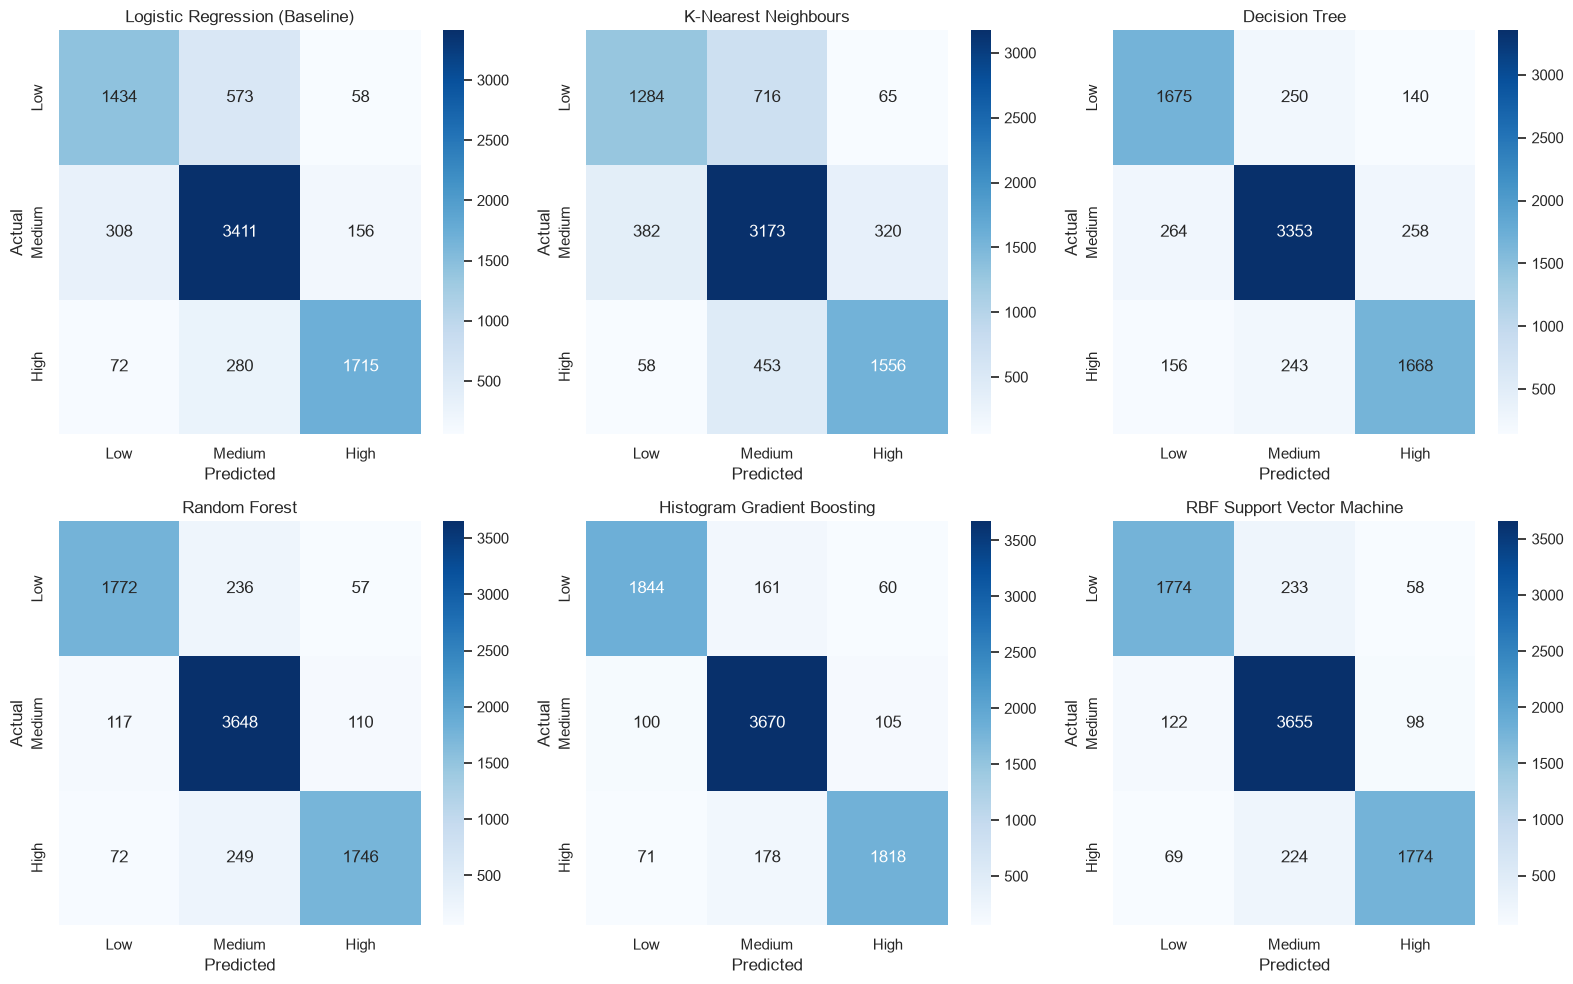

In [24]:
model_results = []
classification_reports = {}
confusion_matrices = {}
fitted_models = {}

if RUN_FULL_MODEL_COMPARISON:
    for model_name, pipeline in MODEL_PIPELINES.items():
        fitted_pipeline = clone(pipeline)
        metrics, report, matrix = evaluate_model(
            model_name,
            fitted_pipeline,
            X_train,
            X_test,
            y_train,
            y_test,
        )
        model_results.append(metrics)
        classification_reports[model_name] = report
        confusion_matrices[model_name] = matrix
        fitted_models[model_name] = fitted_pipeline

    comparison_table = (
        pd.DataFrame(model_results)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )
    display(comparison_table)
    comparison_table.to_csv(TABLES_DIR / "model_comparison.csv", index=False)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for ax, (model_name, matrix) in zip(axes.flat, confusion_matrices.items()):
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=TARGET_ORDER,
            yticklabels=TARGET_ORDER,
            ax=ax,
        )
        ax.set(title=model_name, xlabel="Predicted", ylabel="Actual")
    fig.tight_layout()
    save_and_show(fig, "model_confusion_matrices.png")
else:
    print("Full model comparison is disabled; no comparison table was produced.")

### 8.1 Hyperparameter Tuning

Each candidate configuration was evaluated using five-fold stratified cross-validation on `X_train` and `y_train` only. The configuration with the highest mean macro F1 was selected for each model, then refitted on the complete training set. The held-out test set was not used during tuning. The selected configurations were: Logistic Regression (`C=0.1`, unweighted), KNN (`n_neighbors=31`, uniform Euclidean distance), Random Forest (200 trees, depth 24, `max_features=0.7`, leaf size 1), and Histogram Gradient Boosting (learning rate 0.03, 100 iterations, 63 leaf nodes, L2 regularisation 1.0).

In [25]:
PARAMETER_GRIDS = {
    "Logistic Regression (Baseline)": {
        "model__C": [0.01, 0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"],
    },
    "K-Nearest Neighbours": {
        "model__n_neighbors": [5, 11, 21, 31],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "Decision Tree": {
        "model__max_depth": [None, 8, 16, 24],
        "model__min_samples_leaf": [1, 5, 20],
        "model__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 12, 24],
        "model__min_samples_leaf": [1, 3, 8],
        "model__max_features": ["sqrt", 0.7],
    },
    "Histogram Gradient Boosting": {
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_iter": [100, 200, 350],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    },
    "RBF Support Vector Machine": {
        "model__C": [0.5, 1.0, 5.0],
        "model__gamma": ["scale", 0.01],
    },
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuning_results = {}

if RUN_HYPERPARAMETER_TUNING:
    for model_name, pipeline in MODEL_PIPELINES.items():
        search = GridSearchCV(
            estimator=clone(pipeline),
            param_grid=PARAMETER_GRIDS[model_name],
            scoring="f1_macro",
            cv=CV,
            n_jobs=-1,
            refit=True,
            return_train_score=True,
            verbose=1,
        )
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message=(
                    r"`sklearn\.utils\.parallel\.delayed` should be used with "
                    r"`sklearn\.utils\.parallel\.Parallel`.*"
                ),
                category=UserWarning,
                module=r"sklearn\.utils\.parallel",
            )
            search.fit(X_train, y_train)
        tuning_results[model_name] = search
        print(model_name, search.best_score_, search.best_params_)
else:
    print("Hyperparameter tuning is disabled; no tuned comparison was produced.")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Logistic Regression (Baseline) 0.8181826855254822 {'model__C': 0.1, 'model__class_weight': None}
Fitting 5 folds for each of 16 candidates, totalling 80 fits
K-Nearest Neighbours 0.7983548466182981 {'model__n_neighbors': 31, 'model__p': 2, 'model__weights': 'uniform'}
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Decision Tree 0.8977492288990854 {'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 20}
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Random Forest 0.9153280261880296 {'model__max_depth': 24, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/Users/leongshiwei/ShiWei_Local_Mac/1_Projects/Local_RDS_Y2S1/DS-Asgmt/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Histogram Gradient Boosting 0.9134070620885405 {'model__l2_regularization': 1.0, 'model__learning_rate': 0.03, 'model__max_iter': 100, 'model__max_leaf_nodes': 63}
Fitting 5 folds for each of 6 candidates, totalling 30 fits
RBF Support Vector Machine 0.8952436582339311 {'model__C': 1.0, 'model__gamma': 'scale'}


### 8.2 Evaluation and selection rationale

The tuned comparison is interpreted using macro F1 first, followed by held-out accuracy, weighted F1, class-level recall, confusion matrices, ROC-AUC, train-test gaps, and fit time. This avoids selecting a model from test accuracy alone. The final ranking is based on five-fold cross-validated macro F1, with the untouched test results used as supporting evidence.

### 8.3 Final Tuned Model Comparison

The tuned pipelines are compared on the untouched test set. Random Forest ranks first by cross-validated macro F1 (0.9153) and also achieves the highest test macro F1 (0.9116) and test accuracy (0.9164). Histogram Gradient Boosting is close behind at 0.9134 cross-validated macro F1 and 0.9103 test macro F1. Logistic Regression and KNN remain substantially lower at 0.8120 and 0.7988 test macro F1 respectively.

Random Forest is therefore selected under the predeclared macro-F1 rule, but the margin over Histogram Gradient Boosting is small. The perfect Random Forest training accuracy indicates that repeated or external validation is needed before any operational use.

In [26]:
tuned_model_results = []
tuned_classification_reports = {}
tuned_confusion_matrices = {}
tuned_fitted_models = {}
best_cv_model = None

if RUN_HYPERPARAMETER_TUNING:
    for model_name, search in tuning_results.items():
        tuned_pipeline = clone(search.best_estimator_)
        metrics, report, matrix = evaluate_model(
            model_name,
            tuned_pipeline,
            X_train,
            X_test,
            y_train,
            y_test,
        )
        metrics["cv_macro_f1"] = search.best_score_
        metrics["test_macro_f1"] = metrics["macro_f1"]
        tuned_model_results.append(metrics)
        tuned_classification_reports[model_name] = report
        tuned_confusion_matrices[model_name] = matrix
        tuned_fitted_models[model_name] = tuned_pipeline

    tuned_comparison_table = (
        pd.DataFrame(tuned_model_results)
        .sort_values(["cv_macro_f1", "test_macro_f1"], ascending=False)
        .reset_index(drop=True)
    )
    best_cv_model = tuned_comparison_table.loc[0, "model"]

    display(
        tuned_comparison_table[
            [
                "model",
                "cv_macro_f1",
                "test_macro_f1",
                "test_accuracy",
                "macro_recall",
                "weighted_f1",
                "fit_seconds",
            ]
        ]
    )
    print(f"Selected model by CV macro F1: {best_cv_model}")
    print("Selection is supported by the held-out metrics shown above.")
    tuned_comparison_table.to_csv(TABLES_DIR / "tuned_model_comparison.csv", index=False)
else:
    print("Tuned comparison unavailable because hyperparameter tuning is disabled.")

,model,cv_macro_f1,test_macro_f1,test_accuracy,macro_recall,weighted_f1,fit_seconds
0,Random Forest,0.9153,0.9116,0.9164,0.9077,0.9162,16.1585
1,Histogram Gradient Boosting,0.9134,0.9103,0.9151,0.9060,0.9148,5.4023
2,Decision Tree,0.8977,0.8951,0.8998,0.8913,0.8996,0.2929
3,RBF Support Vector Machine,0.8952,0.8944,0.8996,0.8869,0.8991,56.4260
4,Logistic Regression (Baseline),0.8182,0.8120,0.8193,0.8013,0.8179,0.1941
5,K-Nearest Neighbours,0.7984,0.7988,0.8130,0.7760,0.8080,0.1269


Selected model by CV macro F1: Random Forest
Selection is supported by the held-out metrics shown above.


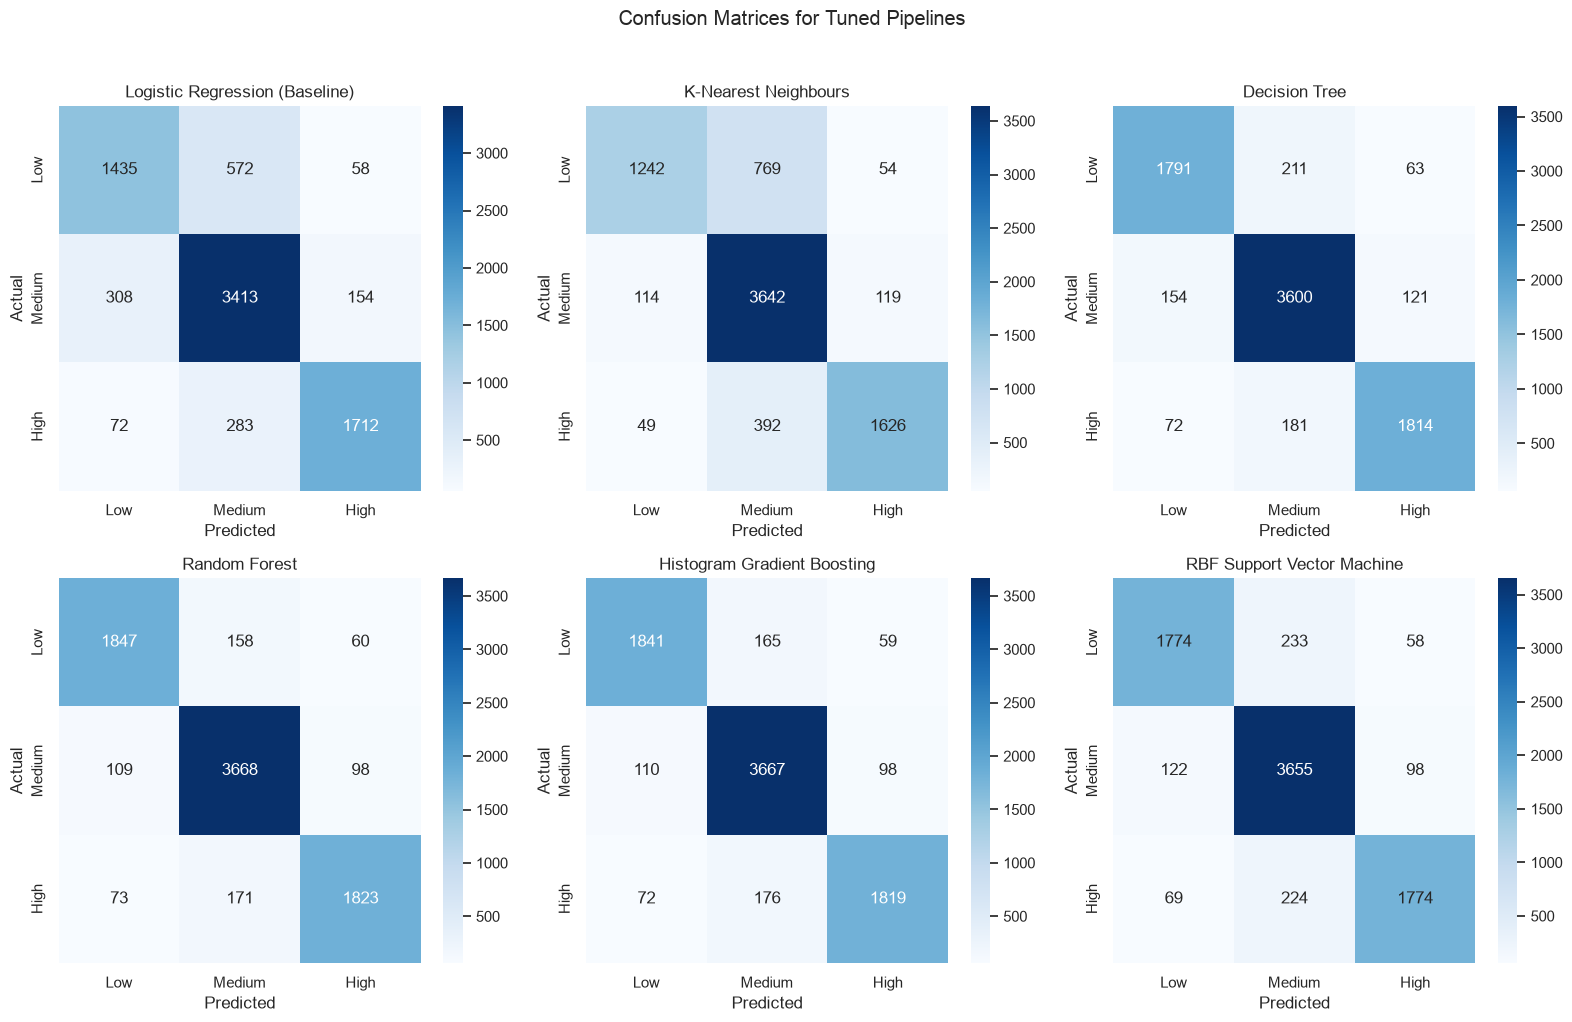

In [27]:
if RUN_HYPERPARAMETER_TUNING:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for ax, model_name in zip(axes.flat, tuned_fitted_models):
        matrix = tuned_confusion_matrices[model_name]
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=TARGET_ORDER,
            yticklabels=TARGET_ORDER,
            ax=ax,
        )
        ax.set(title=model_name, xlabel="Predicted", ylabel="Actual")
    fig.suptitle("Confusion Matrices for Tuned Pipelines", y=1.02)
    fig.tight_layout()
    save_and_show(fig, "tuned_model_confusion_matrices.png")

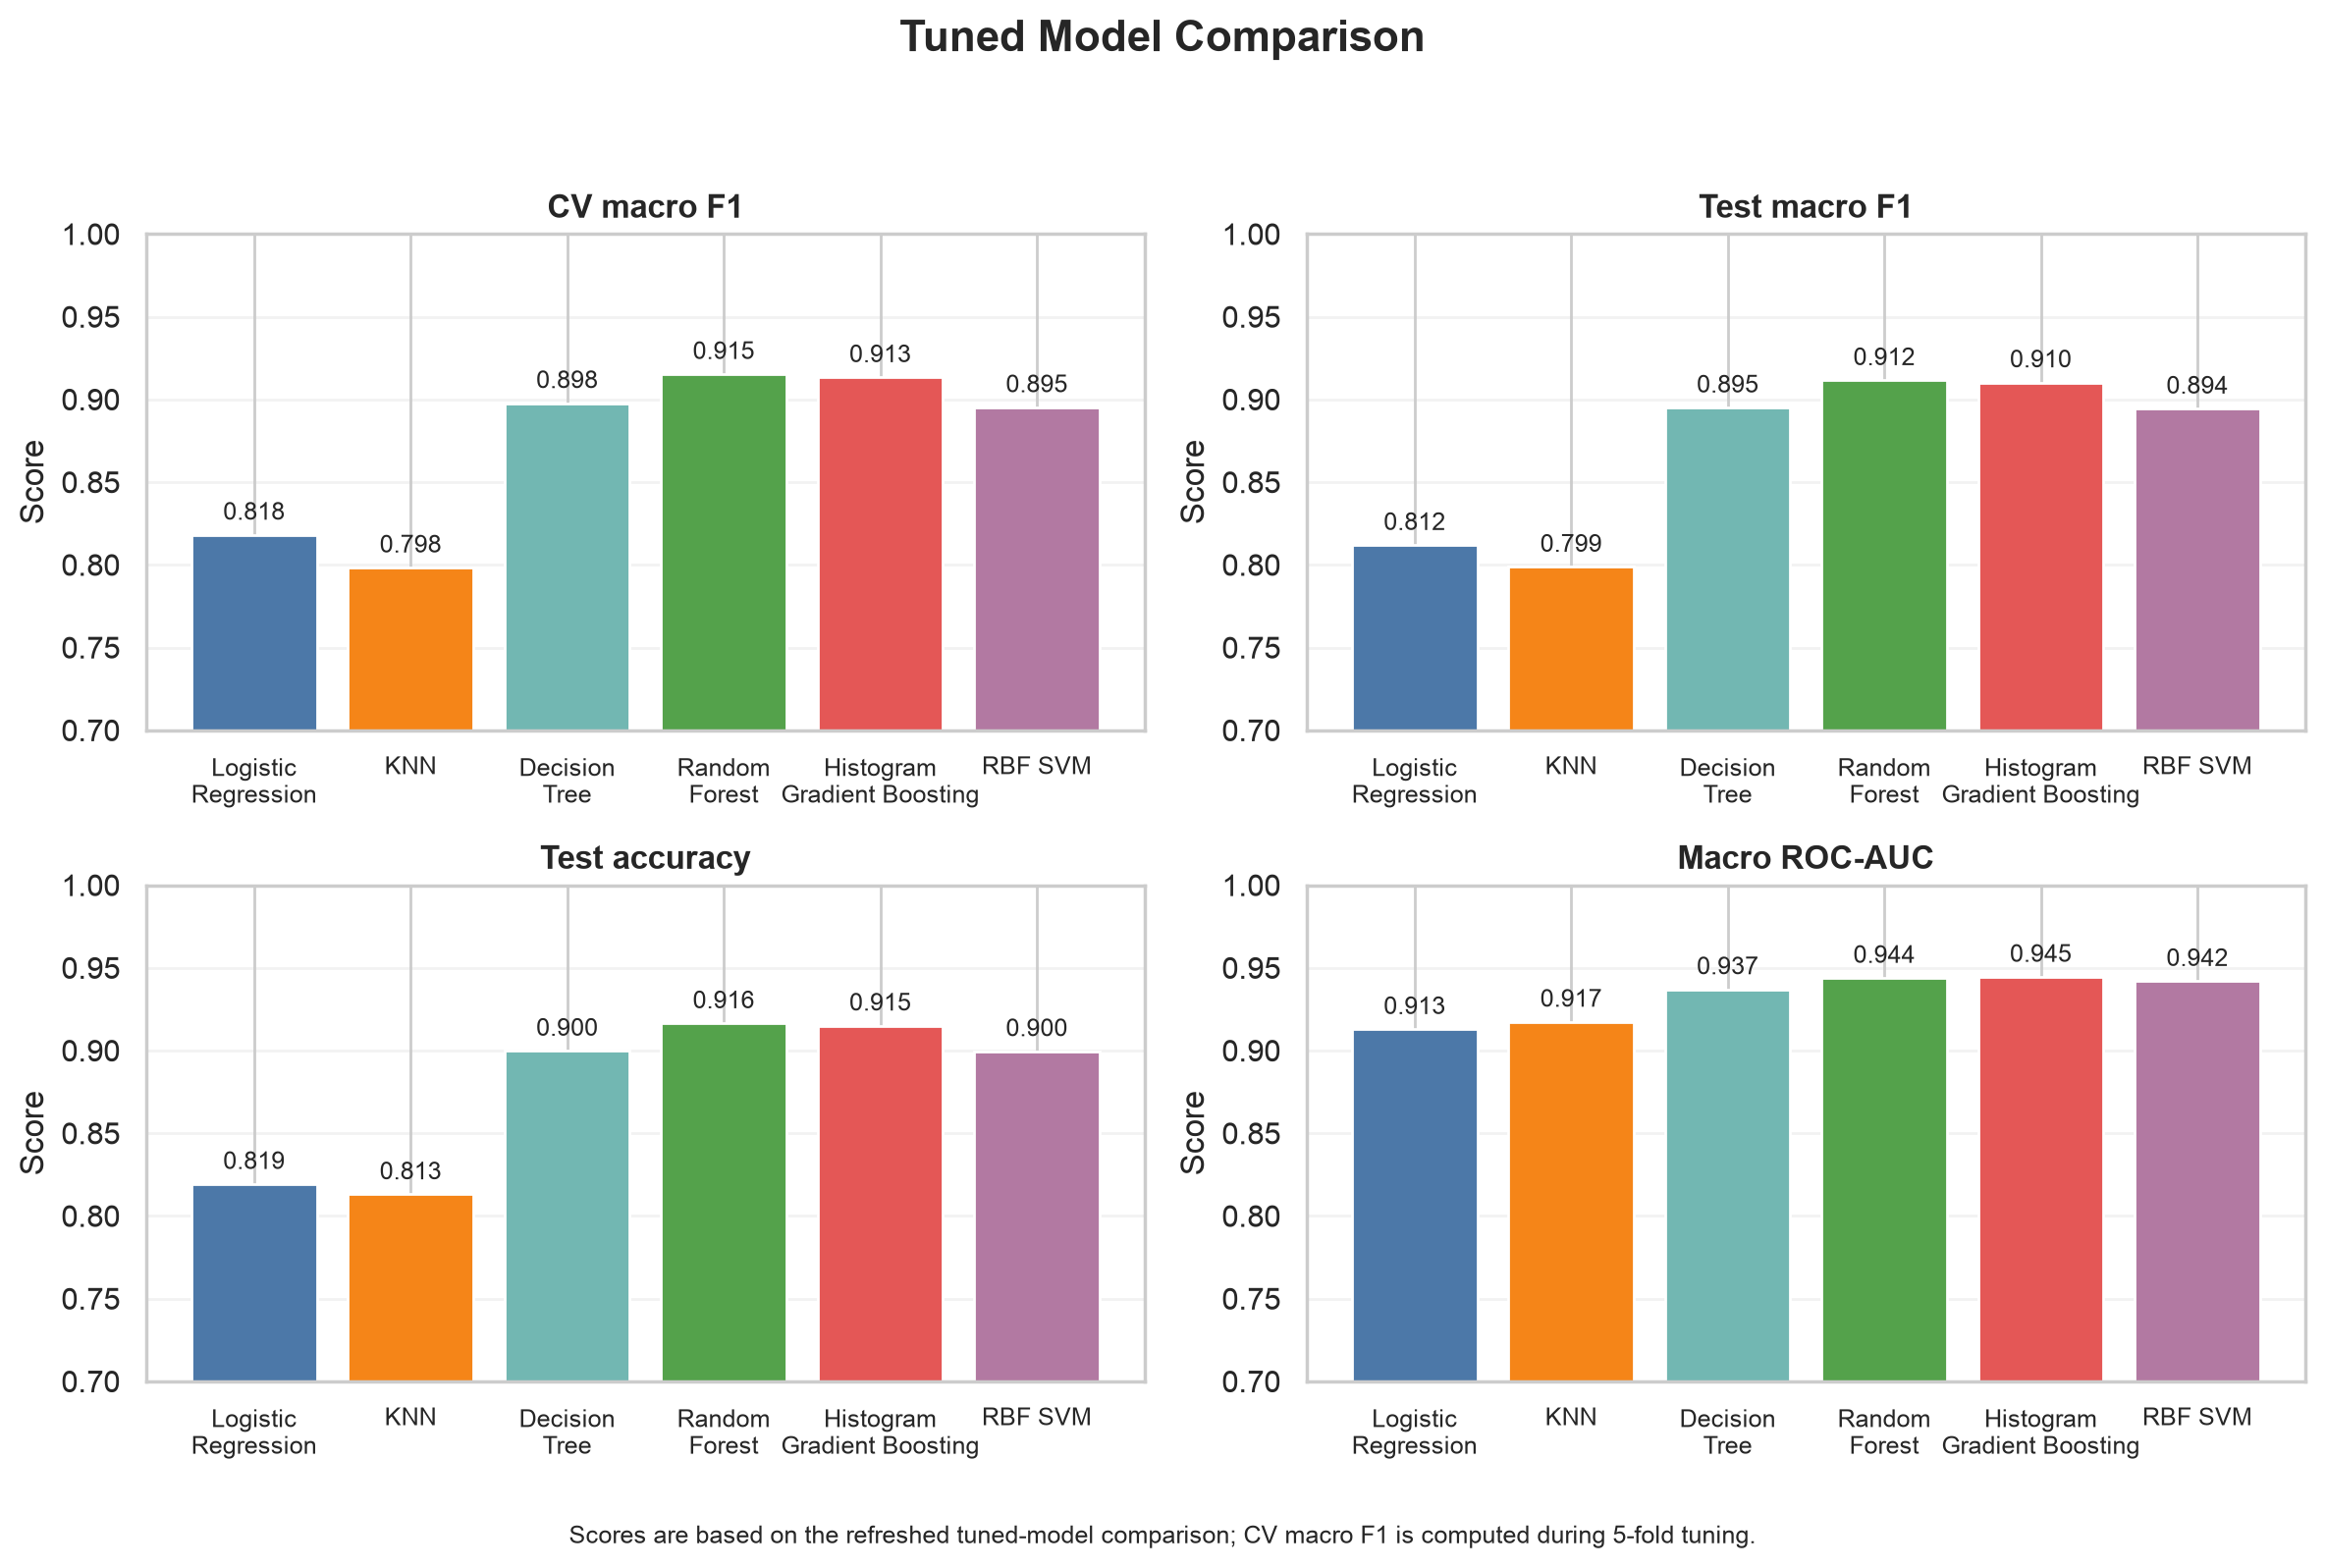

In [28]:
if RUN_HYPERPARAMETER_TUNING and "tuned_comparison_table" in locals():
    plot_table = tuned_comparison_table.copy()
    model_order = [
        "Logistic Regression (Baseline)",
        "K-Nearest Neighbours",
        "Decision Tree",
        "Random Forest",
        "Histogram Gradient Boosting",
        "RBF Support Vector Machine",
    ]
    plot_table["model"] = pd.Categorical(
        plot_table["model"], categories=model_order, ordered=True
    )
    plot_table = plot_table.sort_values("model")
    display_labels = [
        "Logistic\nRegression",
        "KNN",
        "Decision\nTree",
        "Random\nForest",
        "Histogram\nGradient Boosting",
        "RBF SVM",
    ]
    comparison_metrics = [
        ("cv_macro_f1", "CV macro F1"),
        ("test_macro_f1", "Test macro F1"),
        ("test_accuracy", "Test accuracy"),
        ("macro_roc_auc_ovr", "Macro ROC-AUC"),
    ]
    colors = ["#4C78A8", "#F58518", "#72B7B2", "#54A24B", "#E45756", "#B279A2"]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=200)
    for ax, (column, title) in zip(axes.flat, comparison_metrics):
        values = plot_table[column].to_numpy()
        bars = ax.bar(display_labels, values, color=colors, edgecolor="white")
        ax.set_title(title, fontweight="bold")
        ax.set_ylim(0.70, 1.00)
        ax.set_ylabel("Score")
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.006,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        ax.tick_params(axis="x", labelsize=9)
    fig.suptitle("Tuned Model Comparison", fontsize=16, fontweight="bold", y=0.98)
    fig.text(
        0.5,
        0.01,
        "Scores are based on the refreshed tuned-model comparison; "
        "CV macro F1 is computed during 5-fold tuning.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=[0, 0.04, 1, 0.94])
    save_and_show(fig, "tuned_model_comparison.png")
else:
    print("Tuned comparison plot unavailable because hyperparameter tuning is disabled.")

### Report figure placeholders — Modelling and Evaluation

Copy these generated figures into the Google Docs report after the tuned results have been refreshed.

- **Figure 5.1:** `outputs/figures/tuned_model_comparison.png` — Six-model comparison of CV macro F1, test macro F1, test accuracy, and macro ROC-AUC.
- **Figure 5.2:** `outputs/figures/tuned_model_confusion_matrices.png` — Six tuned confusion-matrix panels. Use the relevant model panel in each Section 4 model writeup rather than reproducing numeric matrix tables.

Rows are actual engagement classes and columns are predicted classes, ordered `Low`, `Medium`, `High`.

## 9. Interpretation and Business Implications

The clearest visible predictors of engagement in the supplied data are `SessionsPerWeek` and `AvgSessionDurationMinutes`, followed by progression-related variables such as `PlayerLevel` and `AchievementsUnlocked`. The selected Random Forest identifies the three classes with balanced but not identical recall: `Medium` is easiest to identify (0.9466), while `High` is the most difficult of the three for this model (0.8820).

These patterns can support segment-level investigation, experience analysis, and prioritisation of qualitative research. They should not be used to infer that a particular behaviour causes engagement, to make automated decisions about individual players, or to encourage excessive play or spending. Performance and responsible-use implications should also be checked across available demographic and gameplay subgroups before any deployment decision.

## 10. Prototype Preparation

The executed notebook exports `all_engagement_models.joblib` together with `all_engagement_models_metadata.json`. The artifact contains the complete fitted pipelines for all six tuned models, including preprocessing, so prediction-time transformations remain identical to the training workflow. The metadata records the target, class order, numeric and categorical feature lists, and random seed.

In [29]:
if EXPORT_SELECTED_MODEL:
    if RUN_HYPERPARAMETER_TUNING and tuned_fitted_models:
        export_models = tuned_fitted_models
    elif RUN_FULL_MODEL_COMPARISON and fitted_models:
        export_models = fitted_models
    else:
        raise RuntimeError("Model comparison is required before exporting artifacts.")

    artifact_path = MODELS_DIR / "all_engagement_models.joblib"
    metadata_path = MODELS_DIR / "all_engagement_models_metadata.json"
    joblib.dump(export_models, artifact_path)
    metadata = {
        "models": sorted(export_models),
        "target": TARGET_COLUMN,
        "target_order": TARGET_ORDER,
        "numeric_features": MODEL_NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "random_state": RANDOM_STATE,
    }
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    print(f"Exported models: {sorted(export_models)}")
    print(f"Saved {artifact_path.name} and {metadata_path.name}")
else:
    print("Model export disabled.")

Exported models: ['Decision Tree', 'Histogram Gradient Boosting', 'K-Nearest Neighbours', 'Logistic Regression (Baseline)', 'RBF Support Vector Machine', 'Random Forest']
Saved all_engagement_models.joblib and all_engagement_models_metadata.json


### 10.1 Prototype interface and responsible use

A prototype consuming this artifact should validate the ten required feature names and their permitted ranges before prediction, return one of the three target labels, and communicate probability outputs as model scores rather than calibrated real-world probabilities. The interface should retain the decision-support disclaimer and prohibit manipulative or discriminatory use. Input drift, missingness, category drift, calibration, and class-specific recall are the relevant monitoring signals if the model is taken beyond this assignment.

## 11. Limitations, Reproducibility, and Conclusion

This analysis is limited by the synthetic, cross-sectional dataset, undisclosed target-construction process, absence of a time dimension, and lack of external validation. The strong class separation may reflect the way the labels were simulated. The selected Random Forest also has perfect training accuracy, so the held-out result should not be treated as a production estimate. Calibration, subgroup performance, temporal validation, and repeated or nested validation were outside the scope of this executed notebook.

The technical workflow is reproducible: the schema is validated, the identifier and ambiguous feature are excluded, preprocessing is learned within pipelines, the split and cross-validation use seed 42, and the fitted artifacts are exported with metadata. The final analytical conclusion is that Random Forest is the best-performing candidate under the stated macro-F1 rule, while Histogram Gradient Boosting is a credible stability alternative. Any future operational use would require verification of the target definition, validation on real and time-ordered data, calibration, subgroup checks, monitoring, and responsible-use review.